In [ ]:
import argparse, time, os
import random

from tqdm import tqdm
import copy, math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from pyproj import Proj, Transformer, Geod
import xarray
import xrspatial.slope
from bokeh.models import PrintfTickFormatter, FixedTicker
import datashader as ds
import holoviews as hv
from holoviews import opts
from holoviews.operation.datashader import datashade, rasterize, inspect_points
import hvplot.xarray
import hvplot.pandas
import rioxarray
from rasterio.enums import Resampling


In [2]:
file_path = '/media/maffe/sturellone/CReSIS_Antarctica_Morlighem_personal_dataset/AntarcticaCReSIS_2002_2023.nc'

In [4]:
data = xarray.open_dataset(file_path, decode_coords="all")
print(data)

<xarray.Dataset>
Dimensions:    (length: 27554329)
Dimensions without coordinates: length
Data variables: (12/14)
    lat        (length) float32 ...
    lon        (length) float32 ...
    time       (length) float32 ...
    thickness  (length) float32 ...
    elevation  (length) float32 ...
    frame      (length) float64 ...
    ...         ...
    quality    (length) int16 ...
    exclude    (length) int8 ...
    x          (length) float64 ...
    y          (length) float64 ...
    dataindex  (length) int16 ...
    year       (length) float32 ...
Attributes:
    Conventions:  CF-1.4
    Title:        Filtered CReSIS product
    Author:       Mathieu Morlighem
    version:      19-Dec-2024


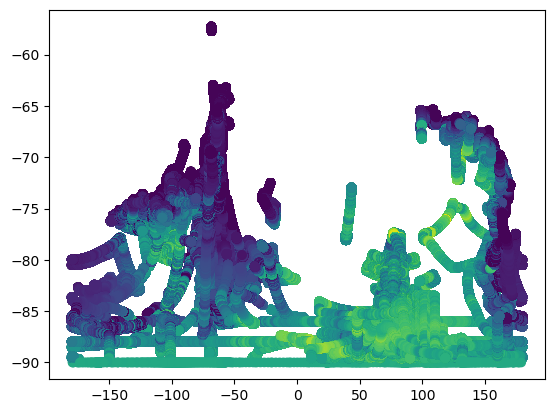

In [5]:
data_x = data.lon.values
data_y = data.lat.values
data_t = data.thickness.values

fig, ax = plt.subplots()
s = ax.scatter(data_x, data_y, c=data_t)
plt.show()


In [6]:
# plot

points = hv.Points(
    {
        'lon': data.lon.values,
        'lat': data.lat.values,
        'thickness': data.thickness.values,
    },
    kdims=['lon', 'lat'],
    vdims=['thickness'],
)

datashade(points)

:DynamicMap   []
   :RGB   [lon,lat]   (R,G,B,A)